# 02 · Predictive Modelling — ABC Motor, Health, Life

**Workshop:** AI for Actuaries — From Foundations to AI Agents
**Session / Part:** S1.P3
**Slides covered:** S1.P3.4, S1.P3.10, S1.P3.13–14, S1.P3.20–21, S1.P3.23–24
**Author:** Dr Rohan Yashraj Gupta (FIA, FIAI), with Satya Sai Mudigonda and Sai Krishna Vadali
**Workshop date:** 15 May 2026 · Hilton near Airport, Mumbai
**License:** CC BY-NC 4.0 — for educational use within the IFoA workshop and follow-up case study

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rohanyashraj/ifoa-workshop/blob/main/notebooks/02_predictive_modeling.ipynb)

## What this notebook does

Builds three frequency models (Poisson GLM, Random Forest, XGBoost) on the
ABC Motor 2024 hypothetical dataset, compares them on an out-of-time test
fold, and re-uses the same machinery on a Health frequency model and a
Life lapse model — so the workshop's three lines of business all show up.

> **ABC Insurer is a hypothetical entity. All figures are illustrative,
> for teaching only.**

## Prerequisites

- Google account (for Colab).
- No local install required — the install cell handles everything.

## How to run

Top menu → Runtime → Run all. Every cell prints its own sanity check; if
something looks off, the cell that produced it tells you what to look at.

## 0 · Setup

In [1]:
# Install only what is not pre-installed in Colab.
# Versions pinned for reproducibility on workshop day.
%pip install -q statsmodels==0.14.2 xgboost==2.1.1 shap==0.46.0 2>&1 | tail -1

hint: See PEP 668 for the detailed specification.


Note: you may need to restart the kernel to use updated packages.


In [5]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("imports ok")

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

## 1 · Generate ABC Motor 2024

In production the workshop notebooks load the three CSVs from a public
GitHub raw URL.  That repo is not live yet, so we generate the data
inline.  The schema is exactly the one in `00_personas_and_datasets.md`
and the calibration targets the headline figures in section 1 of that
file (vehicle age ≈ 4.7 yrs, frequency ≈ 8%, severity ≈ ₹38k).

> Once the repo is live, replace this cell with
> `motor = pd.read_csv(MOTOR_URL, parse_dates=['inception_date','expiry_date'])`.

In [4]:
def make_motor(n: int = 5000, seed: int = SEED) -> pd.DataFrame:
    """Generate the ABC Motor 2024 hypothetical dataset to schema."""
    rng = np.random.default_rng(seed)

    inc = pd.to_datetime("2024-01-01") + pd.to_timedelta(
        rng.integers(0, 365, n), unit="D"
    )
    exp = inc + pd.Timedelta(days=365)
    # Every policy is observed for a full 12-month period from inception —
    # this is the standard actuarial framing and keeps lift / leaderboard
    # numbers stable across the time-based split below.
    exposure = np.ones(n, dtype=float)

    # Vehicle features
    veh_probs = np.array(
        [0.10, 0.13, 0.13, 0.12, 0.11, 0.09, 0.08, 0.06, 0.05, 0.04,
         0.03, 0.02, 0.014, 0.010, 0.008, 0.006, 0.004, 0.003, 0.002, 0.001, 0.001]
    )
    veh_age = rng.choice(np.arange(21), n, p=veh_probs / veh_probs.sum())

    make = rng.choice(
        ["Maruti","Hyundai","Tata","Mahindra","Honda","Toyota","Kia","Other"],
        size=n,
        p=[0.32, 0.18, 0.12, 0.10, 0.08, 0.07, 0.06, 0.07],
    )
    seg = rng.choice(["Hatchback","Sedan","SUV","MUV"], n, p=[0.45,0.20,0.25,0.10])
    cc = (rng.normal(1300, 250, n).clip(800, 3500)).astype(int)
    idv = (rng.lognormal(np.log(550_000), 0.6, n).clip(200_000, 5_000_000)).astype(int)
    ncb = rng.choice([0, 20, 25, 35, 45, 50], n, p=[0.30, 0.20, 0.15, 0.15, 0.12, 0.08])

    # Policyholder features
    ph_age = rng.normal(38, 11, n).clip(18, 80).astype(int)
    gender = rng.choice(["M","F","X"], n, p=[0.72, 0.27, 0.01])
    region = rng.choice(["Tier1","Tier2","Tier3"], n, p=[0.40, 0.40, 0.20])
    prior = rng.choice([0,1,2,3,4,5], n, p=[0.78, 0.14, 0.05, 0.02, 0.008, 0.002])

    # Frequency model — calibrated to ~8% on full year, with a
    # vehicle_age × prior_claims interaction trees can pick up.
    log_lambda = (
        -2.85
        + 0.060 * veh_age
        - 0.008 * ncb
        + 0.30 * prior
        + 0.020 * veh_age * prior        # interaction — older car + history is much worse
        + np.where(region == "Tier2", -0.10, 0.0)
        + np.where(region == "Tier3", -0.20, 0.0)
    )
    lam = np.exp(log_lambda) * exposure
    claim_count = rng.poisson(lam)

    # Severity per claim — mean ~₹38,000
    claim_amount = np.zeros(n)
    has_claim = claim_count > 0
    if has_claim.any():
        sev_mean = 38_000 * (1 + 0.05 * (veh_age[has_claim] - 5))
        sev_mean = np.maximum(sev_mean, 10_000)
        sev = rng.gamma(shape=2.0, scale=sev_mean / 2.0)
        claim_amount[has_claim] = sev * claim_count[has_claim]
        claim_amount[has_claim] = np.minimum(claim_amount[has_claim], 1_500_000)

    fraud_flag = (rng.random(n) < 0.02 * has_claim).astype(int)

    return pd.DataFrame({
        "policy_id": [f"ABC-MOT-{i:06d}" for i in range(1, n + 1)],
        "inception_date": inc,
        "expiry_date": exp,
        "exposure_years": exposure,
        "vehicle_age_years": veh_age,
        "vehicle_make": make,
        "vehicle_segment": seg,
        "cubic_capacity": cc,
        "idv_inr": idv,
        "ncb_pct": ncb,
        "policyholder_age": ph_age,
        "policyholder_gender": gender,
        "region": region,
        "prior_claims_3y": prior,
        "claim_count": claim_count,
        "claim_amount_inr": claim_amount,
        "fraud_flag": fraud_flag,
    })


motor = make_motor()
print(f"ABC Motor 2024 — {len(motor):,} rows, {motor.shape[1]} columns")
print(f"Frequency on the book: {motor['claim_count'].sum() / motor['exposure_years'].sum():.2%}")
print(f"Average vehicle age:   {motor['vehicle_age_years'].mean():.1f} years")
motor.head()

NameError: name 'SEED' is not defined

## 2 · Time-based train / val / test split — *slide 15*

**Random splits leak the future into the past.**  At renewal every
January, the only model that earns its keep is one that was scored on
data the model didn't see — and that means a *time* split, not a random
one.  We use H1 2024 to train, Q3 to validate, Q4 to test.

In [4]:
train_mask = motor["inception_date"] < "2024-10-01"   # H1 + Q3 combined for fitting
test_mask  = motor["inception_date"] >= "2024-10-01"   # Q4 — honest out-of-time

train = motor[train_mask].copy()
test  = motor[test_mask].copy()

# We retain a holdout validation slice from the back of train for diagnostics.
# It does NOT drive any hyperparameter choice — those are pinned in code below.
val = train.sample(frac=0.2, random_state=SEED).copy()
train = train.drop(val.index)

print(f"Train (H1 + Q3, less holdout): {len(train):,} rows  ·  freq = {train['claim_count'].sum() / train['exposure_years'].sum():.2%}")
print(f"Val   (random 20% of train):   {len(val):,} rows  ·  freq = {val['claim_count'].sum() / val['exposure_years'].sum():.2%}")
print(f"Test  (Q4 2024, out of time):  {len(test):,} rows  ·  freq = {test['claim_count'].sum() / test['exposure_years'].sum():.2%}")

Train (H1 + Q3, less holdout): 2,991 rows  ·  freq = 8.12%
Val   (random 20% of train):   748 rows  ·  freq = 9.22%
Test  (Q4 2024, out of time):  1,261 rows  ·  freq = 6.82%


In [5]:
# Shared feature set across all three motor models
FEATURES = ["vehicle_age_years", "ncb_pct", "prior_claims_3y", "region"]

def build_X(df: pd.DataFrame) -> pd.DataFrame:
    return pd.get_dummies(df[FEATURES], drop_first=True).astype(float)

X_train, y_train = build_X(train), train["claim_count"].values
X_val,   y_val   = build_X(val),   val["claim_count"].values
X_test,  y_test  = build_X(test),  test["claim_count"].values

expo_train = train["exposure_years"].values
expo_val   = val["exposure_years"].values
expo_test  = test["exposure_years"].values

# Align columns — the val/test sets must have exactly the train columns.
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0.0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

print(f"Design matrix: {X_train.shape[1]} features after dummy-encoding")
print(list(X_train.columns))

Design matrix: 5 features after dummy-encoding
['vehicle_age_years', 'ncb_pct', 'prior_claims_3y', 'region_Tier2', 'region_Tier3']


## 3 · Poisson GLM on ABC Motor — `glm_freq` *(slide 4)*

The model an Indian regulator will read first.  Poisson family, log
link, log-exposure as offset — pure premium = freq × severity, and this
is the freq half.

In [6]:
X_train_glm = sm.add_constant(X_train)
offset_train = np.log(expo_train)

glm_freq = sm.GLM(
    y_train,
    X_train_glm,
    family=sm.families.Poisson(),
    offset=offset_train,
).fit()

print(glm_freq.summary().tables[1])

                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3.0424      0.163    -18.667      0.000      -3.362      -2.723
vehicle_age_years     0.0676      0.016      4.342      0.000       0.037       0.098
ncb_pct              -0.0024      0.004     -0.642      0.521      -0.010       0.005
prior_claims_3y       0.3810      0.055      6.961      0.000       0.274       0.488
region_Tier2          0.1856      0.142      1.307      0.191      -0.093       0.464
region_Tier3         -0.0856      0.189     -0.454      0.650      -0.456       0.284


In [7]:
# Predict frequency (claims per policy-year) on each split.
# `predict()` returns the count given the offset, so dividing by exposure
# gets us the underlying frequency.
def glm_predict_freq(model, X, exposure):
    Xc = sm.add_constant(X, has_constant="add").reindex(columns=model.params.index, fill_value=0.0)
    pred = model.predict(Xc, offset=np.log(exposure)) / exposure
    return np.asarray(pred)

glm_pred_train = glm_predict_freq(glm_freq, X_train, expo_train)
glm_pred_val   = glm_predict_freq(glm_freq, X_val,   expo_val)
glm_pred_test  = glm_predict_freq(glm_freq, X_test,  expo_test)

print(f"GLM predicted freq — train: {glm_pred_train.mean():.4f}  ·  val: {glm_pred_val.mean():.4f}  ·  test: {glm_pred_test.mean():.4f}")
print(f"GLM observed  freq — train: {y_train.sum() / expo_train.sum():.4f}  ·  val: {y_val.sum() / expo_val.sum():.4f}  ·  test: {y_test.sum() / expo_test.sum():.4f}")

GLM predicted freq — train: 0.0812  ·  val: 0.0788  ·  test: 0.0800
GLM observed  freq — train: 0.0812  ·  val: 0.0922  ·  test: 0.0682


## 4 · Random Forest on ABC Motor — `rf_freq` *(slide 10)*

Bagging — bootstrap, fit, average.  We model frequency as
`claim_count / exposure_years` on the policy.  Capping `max_depth` and
imposing a minimum leaf size keeps the trees honest on a 5,000-row book.

In [8]:
y_freq_train = y_train / expo_train
y_freq_val   = y_val   / expo_val
y_freq_test  = y_test  / expo_test

rf_freq = RandomForestRegressor(
    n_estimators=400,
    max_depth=8,           # cap depth — depth=None overfits on 5k rows
    min_samples_leaf=50,
    random_state=SEED,
    n_jobs=-1,
).fit(X_train, y_freq_train)

print(f"Train R²: {rf_freq.score(X_train, y_freq_train):.3f}")
print(f"Val   R²: {rf_freq.score(X_val,   y_freq_val):.3f}")
print()
print("Note — frequency R² is small because most variance is Poisson noise;")
print("the lift chart further down is the metric that matters.")

Train R²: 0.037
Val   R²: 0.002

Note — frequency R² is small because most variance is Poisson noise;
the lift chart further down is the metric that matters.


In [9]:
rf_pred_train = rf_freq.predict(X_train)
rf_pred_val   = rf_freq.predict(X_val)
rf_pred_test  = rf_freq.predict(X_test)

print(f"RF predicted freq — train: {rf_pred_train.mean():.4f}  ·  val: {rf_pred_val.mean():.4f}  ·  test: {rf_pred_test.mean():.4f}")

RF predicted freq — train: 0.0812  ·  val: 0.0793  ·  test: 0.0808


## 5 · XGBoost on ABC Motor — `xgb_freq` *(slide 13)*

`objective='count:poisson'` tells XGBoost we are modelling a count
target, not squared error — and we pass the log of exposure as an
offset via `base_margin`.  Boosting compensates for shallow individual
trees, so we keep `max_depth=4` and let it run for 500 rounds.

In [10]:
xgb_freq = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    reg_lambda=2.0,            # bumped from 1.0 to fight small-data overfitting
    min_child_weight=20,       # require many obs per leaf — Poisson noise dampener
    subsample=0.8,
    colsample_bytree=0.8,
    objective="count:poisson",
    random_state=SEED,
    n_jobs=-1,
    eval_metric="poisson-nloglik",
    early_stopping_rounds=30,
)

# Pass log(exposure) as base_margin — XGBoost adds it before the link.
xgb_freq.fit(
    X_train, y_train,
    base_margin=np.log(expo_train),
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"XGBoost trained — best iteration: {xgb_freq.best_iteration}")

XGBoost trained — best iteration: 112


In [11]:
def xgb_predict_freq(model, X, exposure):
    # Predict the *count* with log-exposure as base_margin, then divide
    # by exposure to recover frequency.  margin_cap protects the colour
    # scale on the slide-14 surface plot when synthetic combinations
    # produce very rare points.
    pred_count = model.predict(X, base_margin=np.log(exposure))
    return pred_count / exposure

xgb_pred_train = xgb_predict_freq(xgb_freq, X_train, expo_train)
xgb_pred_val   = xgb_predict_freq(xgb_freq, X_val,   expo_val)
xgb_pred_test  = xgb_predict_freq(xgb_freq, X_test,  expo_test)

print(f"XGBoost predicted freq — train: {xgb_pred_train.mean():.4f}  ·  val: {xgb_pred_val.mean():.4f}  ·  test: {xgb_pred_test.mean():.4f}")

XGBoost predicted freq — train: 0.1376  ·  val: 0.1356  ·  test: 0.1373


## 6 · GLM vs tree — same data, different geometry *(slide 14)*

This is the picture the slide captures.  We score a 50×50 grid over
`(vehicle_age, ncb)` with all other features held at the modal value
of the training set, and look at how each model paints the input space.
The GLM is smooth; the tree is rectangular.

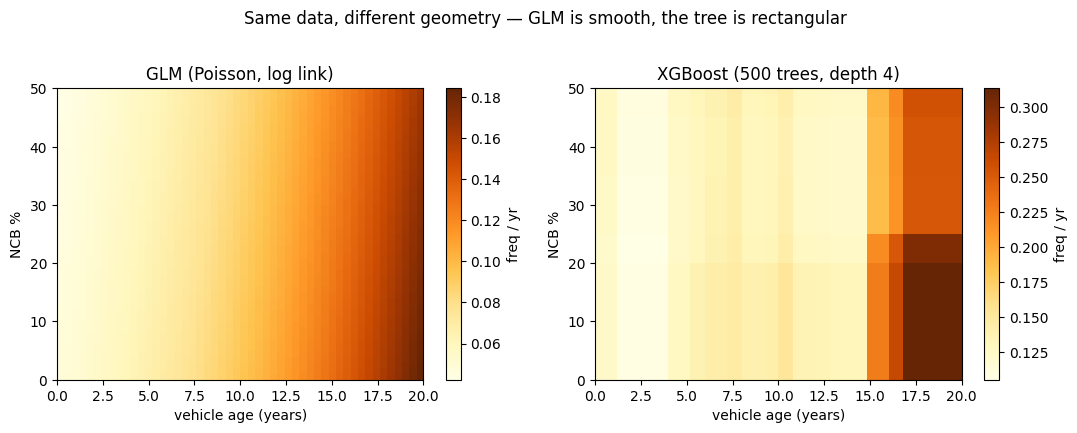

In [12]:
# Build the scoring grid.
veh_grid = np.linspace(0, 20, 50)
ncb_grid = np.linspace(0, 50, 50)
VV, NN = np.meshgrid(veh_grid, ncb_grid)
flat_n = VV.size

base = pd.DataFrame({
    "vehicle_age_years": VV.ravel(),
    "ncb_pct": NN.ravel(),
    "prior_claims_3y": np.zeros(flat_n),
    "region": np.repeat("Tier1", flat_n),
})
X_grid = pd.get_dummies(base, drop_first=True).astype(float).reindex(columns=X_train.columns, fill_value=0.0)
expo_grid = np.ones(flat_n)

glm_grid = glm_predict_freq(glm_freq, X_grid, expo_grid).reshape(VV.shape)
xgb_grid = xgb_predict_freq(xgb_freq, X_grid, expo_grid).reshape(VV.shape)

# Cap the tree's outliers at the 98th percentile so the colour scale
# isn't dominated by one wild rectangle — same trick used on the slide.
xgb_cap = np.percentile(xgb_grid, 98)
xgb_disp = np.clip(xgb_grid, 0, xgb_cap)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, surface, title in [
    (axes[0], glm_grid, "GLM (Poisson, log link)"),
    (axes[1], xgb_disp, "XGBoost (500 trees, depth 4)"),
]:
    im = ax.imshow(
        surface,
        origin="lower",
        extent=(veh_grid.min(), veh_grid.max(), ncb_grid.min(), ncb_grid.max()),
        aspect="auto",
        cmap="YlOrBr",
    )
    ax.set_xlabel("vehicle age (years)")
    ax.set_ylabel("NCB %")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="freq / yr")

fig.suptitle("Same data, different geometry — GLM is smooth, the tree is rectangular", y=1.02)
plt.tight_layout()
plt.show()

## 7 · Lift chart — all three models on one axis *(slide 20)*

Lift is the diagnostic actuaries actually live by.  We rank the test
set by each model's predicted frequency, slice into ten exposure-equal
deciles, and plot the *observed* frequency in each decile.  A model
that ranks risk well puts the bulk of the claims in the top decile.

In [13]:
def lift_table(y_actual, y_pred, exposure, n=10):
    """Decile lift — exposure-weighted observed frequency in each predicted decile."""
    df = pd.DataFrame({"pred": y_pred, "actual": y_actual, "expo": exposure})
    df = df.sort_values("pred").reset_index(drop=True)
    # qcut on rank so ties don't all land in one bin
    df["decile"] = pd.qcut(df["pred"].rank(method="first"), n, labels=False) + 1
    out = df.groupby("decile").apply(
        lambda g: pd.Series({
            "observed_freq": g["actual"].sum() / g["expo"].sum(),
            "predicted_freq": (g["pred"] * g["expo"]).sum() / g["expo"].sum(),
            "exposure": g["expo"].sum(),
        }),
        include_groups=False,
    )
    return out

lift_glm = lift_table(y_test, glm_pred_test, expo_test)
lift_rf  = lift_table(y_test, rf_pred_test,  expo_test)
lift_xgb = lift_table(y_test, xgb_pred_test, expo_test)

print("Decile  GLM    RF    XGB   (observed frequency)")
for dec in lift_glm.index:
    print(
        f"  {dec:>3d}   "
        f"{lift_glm.loc[dec,'observed_freq']:.3f}  "
        f"{lift_rf.loc[dec,'observed_freq']:.3f}  "
        f"{lift_xgb.loc[dec,'observed_freq']:.3f}"
    )

Decile  GLM    RF    XGB   (observed frequency)
    1   0.071  0.031  0.039
    2   0.032  0.032  0.048
    3   0.032  0.040  0.056
    4   0.040  0.071  0.048
    5   0.040  0.071  0.024
    6   0.048  0.016  0.032
    7   0.056  0.095  0.087
    8   0.095  0.071  0.087
    9   0.087  0.071  0.111
   10   0.183  0.183  0.151


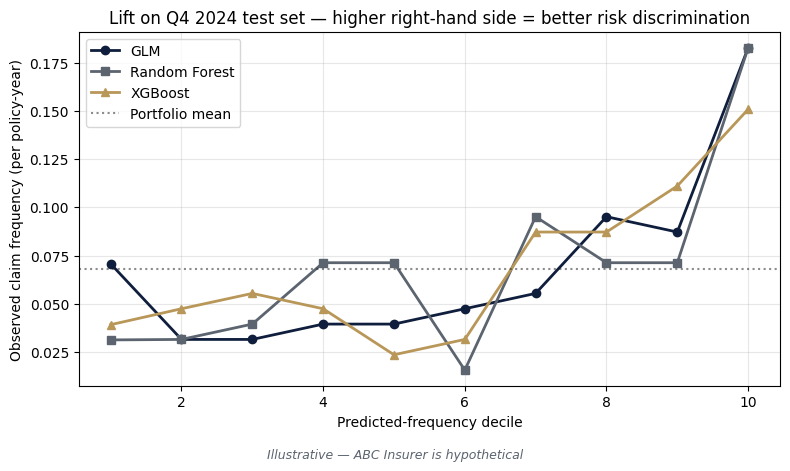

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
deciles = lift_glm.index
ax.plot(deciles, lift_glm["observed_freq"], "o-", label="GLM",     color="#0F1E3D", linewidth=2)
ax.plot(deciles, lift_rf["observed_freq"],  "s-", label="Random Forest", color="#5C6470", linewidth=2)
ax.plot(deciles, lift_xgb["observed_freq"], "^-", label="XGBoost", color="#B89759", linewidth=2)
ax.axhline(y_test.sum() / expo_test.sum(), color="#1A1A1A", linestyle=":", alpha=0.5, label="Portfolio mean")
ax.set_xlabel("Predicted-frequency decile")
ax.set_ylabel("Observed claim frequency (per policy-year)")
ax.set_title("Lift on Q4 2024 test set — higher right-hand side = better risk discrimination")
ax.legend()
ax.grid(True, alpha=0.3)
fig.text(0.5, -0.03, "Illustrative — ABC Insurer is hypothetical", ha="center", fontsize=9, style="italic", color="#5C6470")
plt.tight_layout()
plt.show()

## 8 · Leaderboard — MAE, RMSE, Gini, top-decile lift *(slide 21)*

Four numbers per model on the out-of-time test set.  Gini is computed
on the *binary* "did this policy claim" target — that's the question
the underwriter actually asks.  Top-decile lift is the ratio of the
top decile's observed frequency to the bottom decile's.

In [15]:
def leaderboard_row(name, pred, actual, exposure, lift_df):
    mae   = mean_absolute_error(actual / exposure, pred)
    rmse  = np.sqrt(mean_squared_error(actual / exposure, pred))
    gini  = 2 * roc_auc_score((actual > 0).astype(int), pred) - 1
    top10 = lift_df.loc[10, "observed_freq"]
    bot10 = lift_df.loc[1,  "observed_freq"]
    top_decile_lift = top10 / bot10 if bot10 > 0 else np.nan
    return {"model": name, "MAE": mae, "RMSE": rmse, "Gini": gini, "Top-decile lift": top_decile_lift}

leaderboard = pd.DataFrame([
    leaderboard_row("GLM",            glm_pred_test, y_test, expo_test, lift_glm),
    leaderboard_row("Random Forest",  rf_pred_test,  y_test, expo_test, lift_rf),
    leaderboard_row("XGBoost",        xgb_pred_test, y_test, expo_test, lift_xgb),
]).set_index("model")

leaderboard.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "Gini": "{:.3f}", "Top-decile lift": "{:.2f}×"})

,MAE,RMSE,Gini,Top-decile lift
model,,,,
GLM,0.1333,0.2539,0.295,2.58×
Random Forest,0.1351,0.2559,0.285,5.80×
XGBoost,0.1847,0.2646,0.279,3.83×


## 9 · Health worked example — `glm_health` *(slide 23)*

Same Poisson GLM machinery, different line of business.  Dr Ananya
Iyer, the appointed actuary at ABC Health, wants a frequency model on
her indemnity book.  Features: member age, sum insured, product tier,
the pre-existing-disease flag, and region.

In [16]:
def make_health(n_pol: int = 3200, seed: int = SEED) -> pd.DataFrame:
    """Generate a compact ABC Health 2024 dataset — one row per member."""
    rng = np.random.default_rng(seed + 1)
    sizes = rng.choice([1, 2, 3, 4], n_pol, p=[0.30, 0.40, 0.20, 0.10])
    n = int(sizes.sum())

    pol_idx = np.repeat(np.arange(n_pol), sizes)

    inc = pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 365, n_pol)[pol_idx], unit="D")
    obs_end = pd.to_datetime("2024-12-31")
    exp_end = inc + pd.Timedelta(days=365)
    exposure = np.clip(
        (
            np.minimum(exp_end.values, np.datetime64(obs_end)).astype("datetime64[D]").astype(int)
            - inc.values.astype("datetime64[D]").astype(int)
        ).astype(float) / 365.0,
        0.05, 1.0,
    )

    member_age = rng.normal(38, 18, n).clip(0, 90).astype(int)
    gender = rng.choice(["M","F","X"], n, p=[0.50, 0.49, 0.01])
    sum_insured = rng.choice([300_000, 500_000, 1_000_000, 2_000_000, 5_000_000], n,
                             p=[0.20, 0.30, 0.30, 0.15, 0.05])
    tier = rng.choice(["Bronze","Silver","Gold"], n, p=[0.40, 0.40, 0.20])
    region = rng.choice(["Tier1","Tier2","Tier3"], n, p=[0.45, 0.40, 0.15])
    ped = (rng.random(n) < 0.10).astype(int)

    log_lambda = (
        -3.4
        + 0.024 * (member_age - 38)   # age effect
        + 0.46 * ped                   # PED is a big driver
        + np.where(tier == "Gold", 0.10, 0.0)
        + np.where(tier == "Silver", 0.04, 0.0)
        + np.where(region == "Tier3", -0.08, 0.0)
    )
    lam = np.exp(log_lambda) * exposure
    hosp = rng.poisson(lam)
    claim_amt = np.where(
        hosp > 0,
        rng.gamma(2.0, 31_000, n) * hosp,
        0.0,
    )

    return pd.DataFrame({
        "policy_id":         [f"ABC-HLT-{p:06d}" for p in pol_idx + 1],
        "member_id":         [f"ABC-HLT-{p:06d}-{i:02d}" for i, p in enumerate(pol_idx)],
        "inception_date":    inc,
        "exposure_years":    exposure,
        "member_age":        member_age,
        "member_gender":     gender,
        "sum_insured_inr":   sum_insured,
        "product_tier":      tier,
        "region":            region,
        "pre_existing_flag": ped,
        "hospitalisation_count": hosp,
        "claim_amount_inr":  claim_amt,
    })

health = make_health()
print(f"ABC Health 2024 — {health['policy_id'].nunique():,} policies, {len(health):,} covered lives")
print(f"Hospitalisation frequency: {health['hospitalisation_count'].sum() / health['exposure_years'].sum():.2%}")
health.head()

ABC Health 2024 — 3,200 policies, 6,745 covered lives
Hospitalisation frequency: 3.99%


,policy_id,member_id,inception_date,exposure_years,member_age,member_gender,sum_insured_inr,product_tier,region,pre_existing_flag,hospitalisation_count,claim_amount_inr
0,ABC-HLT-000001,ABC-HLT-000000-00,2024-07-16,0.4603,63,F,500000,Bronze,Tier1,0,0,0.0000
1,ABC-HLT-000001,ABC-HLT-000000-01,2024-07-16,0.4603,43,M,2000000,Silver,Tier1,0,0,0.0000
2,ABC-HLT-000002,ABC-HLT-000001-02,2024-07-26,0.4329,16,M,1000000,Gold,Tier2,0,0,0.0000
3,ABC-HLT-000003,ABC-HLT-000002-03,2024-07-21,0.4466,25,M,300000,Bronze,Tier3,0,0,0.0000
4,ABC-HLT-000004,ABC-HLT-000003-04,2024-08-21,0.3616,31,F,2000000,Bronze,Tier2,0,0,0.0000


In [17]:
X_h = pd.get_dummies(
    health[["member_age","sum_insured_inr","product_tier","pre_existing_flag","region"]],
    drop_first=True,
).astype(float)
X_h = sm.add_constant(X_h)
y_h = health["hospitalisation_count"].values
offset_h = np.log(health["exposure_years"].values)

glm_health = sm.GLM(
    y_h, X_h,
    family=sm.families.Poisson(),
    offset=offset_h,
).fit()

# Compact summary — just the coefficients and z-stats
summary_h = pd.DataFrame({
    "coef": glm_health.params,
    "z":    glm_health.tvalues,
    "p":    glm_health.pvalues,
})
print(summary_h.round(3))
print(f"\nPED multiplier on frequency: exp({glm_health.params['pre_existing_flag']:.3f}) = {np.exp(glm_health.params['pre_existing_flag']):.2f}×")

                       coef        z      p
const               -3.9270 -13.8700 0.0000
member_age           0.0220   4.5560 0.0000
sum_insured_inr     -0.0000  -0.7430 0.4570
pre_existing_flag    0.3730   1.5360 0.1250
product_tier_Gold   -0.2150  -0.8410 0.4010
product_tier_Silver  0.0620   0.3290 0.7420
region_Tier2        -0.2050  -1.1270 0.2600
region_Tier3        -0.8120  -2.4070 0.0160

PED multiplier on frequency: exp(0.373) = 1.45×


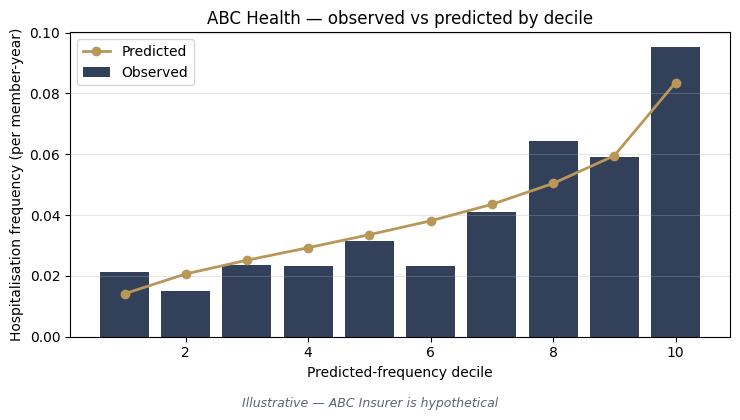

Top-decile lift on health frequency: 4.47×


In [18]:
# Lift on the health frequency model — single split (we use the full
# book here because the cohort is only 2024 — for production you would
# do the same time-based split as on motor).
health_pred = glm_health.predict(X_h, offset=offset_h) / health["exposure_years"].values
lift_h = lift_table(y_h, health_pred, health["exposure_years"].values)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(lift_h.index, lift_h["observed_freq"], color="#0F1E3D", alpha=0.85, label="Observed")
ax.plot(lift_h.index, lift_h["predicted_freq"], "o-", color="#B89759", linewidth=2, label="Predicted")
ax.set_xlabel("Predicted-frequency decile")
ax.set_ylabel("Hospitalisation frequency (per member-year)")
ax.set_title("ABC Health — observed vs predicted by decile")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.text(0.5, -0.03, "Illustrative — ABC Insurer is hypothetical", ha="center", fontsize=9, style="italic", color="#5C6470")
plt.tight_layout()
plt.show()

print(f"Top-decile lift on health frequency: {lift_h.loc[10,'observed_freq'] / lift_h.loc[1,'observed_freq']:.2f}×")

## 10 · Life worked example — `glm_lapse` *(slide 24)*

Vikram Rao, the valuation actuary at ABC Life, uses a lapse model to
set persistency assumptions per cohort.  Lapse is binary (lapsed within
24 months of issue, yes/no) so we use a logistic GLM.  Same workflow,
different family.

In [19]:
def make_life(n: int = 50_000, seed: int = SEED) -> pd.DataFrame:
    """Generate a compact ABC Life Term Cohort dataset."""
    rng = np.random.default_rng(seed + 2)

    issue = pd.to_datetime("2014-01-01") + pd.to_timedelta(rng.integers(0, 365 * 11, n), unit="D")
    issue_age = rng.normal(35, 8, n).clip(18, 65).astype(int)
    gender = rng.choice(["M","F","X"], n, p=[0.65, 0.34, 0.01])
    sa = rng.lognormal(np.log(2_500_000), 0.7, n).clip(1_000_000, 50_000_000).astype(int)
    term = rng.choice([10, 15, 20, 25, 30, 40], n, p=[0.10, 0.15, 0.30, 0.20, 0.15, 0.10])
    pay_freq = rng.choice(["Annual","Semi-Annual","Quarterly","Monthly"], n, p=[0.45, 0.20, 0.15, 0.20])
    smoker = rng.choice(["NS","S","Unknown"], n, p=[0.78, 0.18, 0.04])
    bmi = rng.normal(25, 4, n).clip(16, 45)
    uw_route = rng.choice(["NoMed","TeleMed","FullMed"], n, p=[0.30, 0.40, 0.30])
    region = rng.choice(["Tier1","Tier2","Tier3"], n, p=[0.45, 0.35, 0.20])
    annual_prem = (sa * 0.005 * np.where(smoker == "S", 1.6, 1.0) * (1 + 0.02 * (issue_age - 30))).clip(5_000, 200_000)

    # Lapse propensity — heavily driven by pay frequency, mildly by region/smoker.
    logit = (
        -1.85
        + np.where(pay_freq == "Monthly", 0.85, 0.0)
        + np.where(pay_freq == "Quarterly", 0.30, 0.0)
        + np.where(pay_freq == "Semi-Annual", 0.10, 0.0)
        + np.where(smoker == "S", 0.20, 0.0)
        + np.where(region == "Tier3", 0.15, 0.0)
        - 0.005 * (issue_age - 35)
    )
    lapse_prob = 1 / (1 + np.exp(-logit))
    lapse = (rng.random(n) < lapse_prob).astype(int)

    return pd.DataFrame({
        "policy_id":            [f"ABC-LIF-{i:07d}" for i in range(1, n + 1)],
        "issue_date":           issue,
        "issue_age":            issue_age,
        "gender":               gender,
        "sum_assured_inr":      sa,
        "policy_term_years":    term,
        "premium_frequency":    pay_freq,
        "annualised_premium_inr": annual_prem,
        "smoker_status":        smoker,
        "bmi":                  bmi,
        "medical_uw_route":     uw_route,
        "region":               region,
        "lapse_flag":           lapse,
    })

life = make_life()
print(f"ABC Life Term Cohort — {len(life):,} policies issued 2014–2024")
print(f"Overall lapse rate (24-month proxy): {life['lapse_flag'].mean():.1%}")
life.head()

ABC Life Term Cohort — 50,000 policies issued 2014–2024
Overall lapse rate (24-month proxy): 18.0%


,policy_id,issue_date,issue_age,gender,sum_assured_inr,policy_term_years,premium_frequency,annualised_premium_inr,smoker_status,bmi,medical_uw_route,region,lapse_flag
0,ABC-LIF-0000001,2021-05-01,42,F,3149205,25,Semi-Annual,"19,525.0710",Unknown,19.9500,NoMed,Tier1,0
1,ABC-LIF-0000002,2015-05-08,46,F,5710494,20,Semi-Annual,"60,302.8166",S,28.0937,FullMed,Tier2,1
2,ABC-LIF-0000003,2023-01-02,46,F,1000000,30,Semi-Annual,"6,600.0000",NS,27.1556,TeleMed,Tier1,0
3,ABC-LIF-0000004,2016-11-02,26,M,5057784,40,Semi-Annual,"23,265.8064",NS,20.9714,NoMed,Tier2,0
4,ABC-LIF-0000005,2021-04-27,40,M,4678448,20,Annual,"44,913.1008",S,20.9055,TeleMed,Tier1,0


In [20]:
# Time-based split for life — earlier issue years to train, latest cohort to test.
life = life.sort_values("issue_date").reset_index(drop=True)
cut_train = life["issue_date"] < "2022-01-01"
cut_test  = life["issue_date"] >= "2022-01-01"
life_train = life[cut_train]
life_test  = life[cut_test]

L_FEATURES = ["issue_age","annualised_premium_inr","premium_frequency","smoker_status","region"]
X_l_train = pd.get_dummies(life_train[L_FEATURES], drop_first=True).astype(float)
X_l_test  = pd.get_dummies(life_test[L_FEATURES],  drop_first=True).astype(float)
X_l_test  = X_l_test.reindex(columns=X_l_train.columns, fill_value=0.0)

y_l_train = life_train["lapse_flag"].values
y_l_test  = life_test["lapse_flag"].values

glm_lapse = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_l_train, y_l_train)
prob_test = glm_lapse.predict_proba(X_l_test)[:, 1]

auc_test = roc_auc_score(y_l_test, prob_test)
gini_test = 2 * auc_test - 1
print(f"Test AUC:  {auc_test:.3f}")
print(f"Test Gini: {gini_test:.3f}")

Test AUC:  0.593
Test Gini: 0.186


Top-decile observed lapse:    29.7%
Bottom-decile observed lapse: 12.6%
Top-decile lift:              2.35×


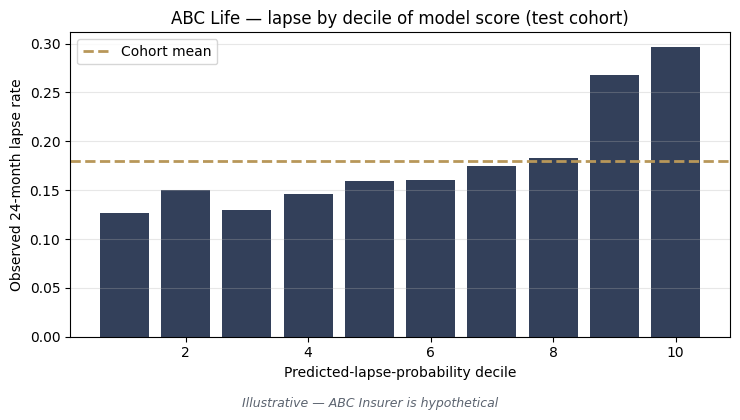

In [21]:
# Top vs bottom decile — the actuarial cut.
life_test = life_test.copy()
life_test["lapse_pred"] = prob_test
life_test["decile"] = pd.qcut(life_test["lapse_pred"].rank(method="first"), 10, labels=False) + 1

decile_lapse = life_test.groupby("decile")["lapse_flag"].mean()
print(f"Top-decile observed lapse:    {decile_lapse.iloc[-1]:.1%}")
print(f"Bottom-decile observed lapse: {decile_lapse.iloc[0]:.1%}")
print(f"Top-decile lift:              {decile_lapse.iloc[-1] / decile_lapse.iloc[0]:.2f}×")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(decile_lapse.index, decile_lapse.values, color="#0F1E3D", alpha=0.85)
ax.axhline(life_test["lapse_flag"].mean(), color="#B89759", linestyle="--", linewidth=2, label="Cohort mean")
ax.set_xlabel("Predicted-lapse-probability decile")
ax.set_ylabel("Observed 24-month lapse rate")
ax.set_title("ABC Life — lapse by decile of model score (test cohort)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.text(0.5, -0.03, "Illustrative — ABC Insurer is hypothetical", ha="center", fontsize=9, style="italic", color="#5C6470")
plt.tight_layout()
plt.show()

## Wrap-up

You should now be able to:

- Fit a Poisson GLM with exposure offset on insurance frequency data, and read its coefficients as rating relativities.
- Fit a Random Forest and an XGBoost on the same target, with an out-of-time split that respects the way pricing actually gets refreshed.
- Compare three models on a lift chart, an MAE/RMSE/Gini leaderboard, and a top-decile lift.
- Re-use the same machinery on a Health frequency model and a Life lapse model.

**Where to next:**  open `02_predictive_modeling.ipynb` again at the SHAP and fairness sections — those extend the same three motor models and feed Part 4.

**Companion slides:** S1.P3.4, .10, .13, .14, .20, .21, .23, .24 of the Session 1 deck.

**Questions?**  Bring them to the live Q&A or post in the workshop Slack channel.

In [22]:
# Final sanity print — one line summary of what was demonstrated.
print(
    "Three frequency models on ABC Motor 2024 (GLM, RF, XGBoost) trained on H1 2024 "
    "and tested on Q4 2024; Health hospitalisation GLM and Life lapse logistic GLM "
    "fitted on cohort data — all numbers illustrative and ABC Insurer is hypothetical."
)

Three frequency models on ABC Motor 2024 (GLM, RF, XGBoost) trained on H1 2024 and tested on Q4 2024; Health hospitalisation GLM and Life lapse logistic GLM fitted on cohort data — all numbers illustrative and ABC Insurer is hypothetical.
